# Building a Neural Network from Scratch: Breast Cancer Classification

## Introduction

Neural networks form the foundation of modern machine learning. In this notebook, we'll build a neural network from the ground up using Python and NumPy to understand the core concepts. We'll start with basic components and gradually progress to a complete model capable of classifying breast cancer as benign or malignant.

## Roadmap

This notebook is organized into the following sections:

1. **Creating a basic neuron with sigmoid activation**
2. **Training a single neuron to learn the AND gate operation**
3. **Visualizing neural transformations in 3D space**
4. **Exploring the XOR problem and why a single neuron can't solve it**
5. **Building a complete neural network for the Breast Cancer dataset**
6. **Implementing advanced techniques to improve performance**
7. **Analyzing our model's predictions**



###1. Basic Neuron Implementation
The fundamental building block of neural networks is the neuron. Each neuron:

Takes multiple inputs
Applies weights to these inputs
Adds a bias term
Passes the result through an activation function



In [1]:
import numpy as np

def neuron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights) + bias

    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    return sigmoid(weighted_sum)


### 2. The AND Gate: Training a Single Neuron
Before tackling complex problems, let's see if a neuron can learn a simple logical operation. The AND gate outputs 1 only when both inputs are 1, otherwise it outputs 0.



Here, we'll train a single neuron using gradient descent:

Epoch 0, Loss: 0.4098
Epoch 1000, Loss: 0.0317
Epoch 2000, Loss: 0.0156
Epoch 3000, Loss: 0.0100
Epoch 4000, Loss: 0.0073
Epoch 5000, Loss: 0.0057
Epoch 6000, Loss: 0.0046
Epoch 7000, Loss: 0.0039
Epoch 8000, Loss: 0.0034
Epoch 9000, Loss: 0.0030


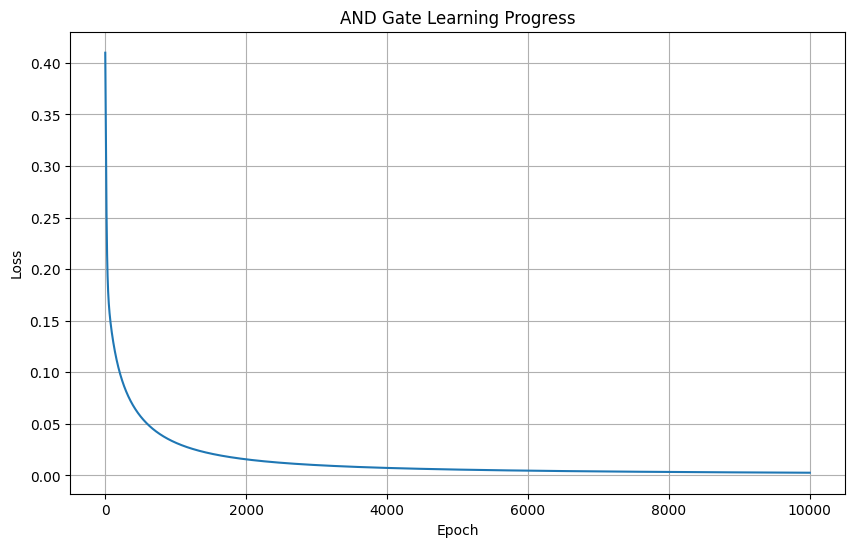

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def train_neuron(inputs, expected_outputs, learning_rate=0.1, epochs=10000):
    weights = np.random.random(inputs.shape[1])
    bias = np.random.random()
    loss_history = []  # To track progress

    for epoch in range(epochs):
        total_loss = 0
        for i in range(len(inputs)):
            weighted_sum = np.dot(inputs[i], weights) + bias
            prediction = 1 / (1 + np.exp(-weighted_sum))  # Sigmoid

            error = expected_outputs[i] - prediction
            total_loss += error ** 2

            gradient = prediction * (1 - prediction)
            weights += learning_rate * error * gradient * inputs[i]
            bias += learning_rate * error * gradient

        avg_loss = total_loss / len(inputs)
        loss_history.append(avg_loss)

        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

    return weights, bias, loss_history

# Example Inputs for AND Gate
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
expected_outputs = np.array([0, 0, 0, 1])

# Train the neuron
weights, bias, loss_history = train_neuron(inputs, expected_outputs)

# After training, plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title('AND Gate Learning Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


#### Understanding the Loss Curve
The decreasing loss values show that our model is learning the AND operation over time. Starting at around 0.41, the loss decreases to about 0.003 by epoch 9000, indicating improved accuracy.

####Visualizing the Decision Boundary:
To understand what the neuron has learned, we can visualize the decision boundary:

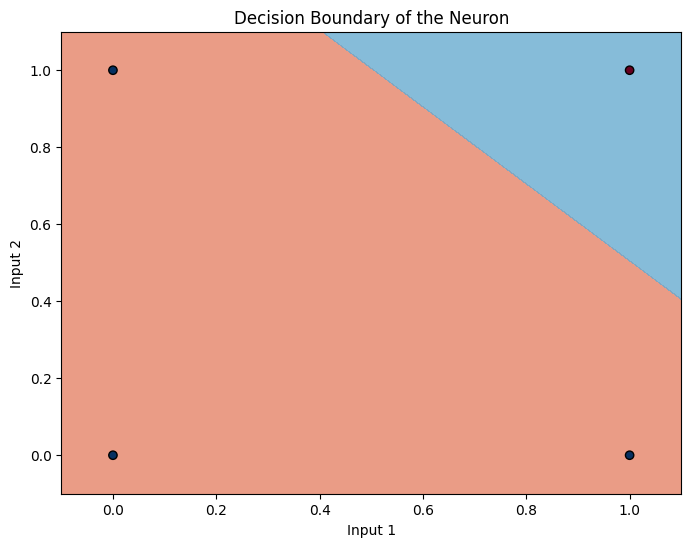

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Simple neuron function
def neuron(inputs, weights, bias):
    return np.dot(inputs, weights) + bias > 0  # Decision threshold is 0

def plot_decision_boundary(X, y, weights, bias):
    # Create a grid of points for the plot
    h = 0.01  # Step size for grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict for each point in the grid
    Z = np.array([neuron(np.array([x1, x2]), weights, bias) for x1, x2 in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)  # Decision boundary
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k')  # Data points
    plt.title('Decision Boundary of the Neuron')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.show()

# Example inputs and expected outputs (AND Gate)
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
expected_outputs = np.array([0, 0, 0, 1])

weights = np.array([1, 1])  # Weights for each input
bias = -1.5  # Bias value for the neuron

plot_decision_boundary(inputs, expected_outputs, weights, bias)


###Decision Boundary for the AND gate

The resulting plot shows a clean separation between the (1,1) point and the other points, confirming that our neuron correctly learned the AND operation.



###The XOR problem
The XOR (exclusive OR) problem is a classic example in neural network training. It involves learning a non-linear relationship between the input and output. The XOR gate outputs 1 when the inputs are different (i.e., 0 XOR 1 = 1 and 1 XOR 0 = 1), and it outputs 0 when both inputs are the same (i.e., 0 XOR 0 = 0 and 1 XOR 1 = 0).

The XOR Problem
The challenge with the XOR problem is that it is not linearly separable, which means that you cannot draw a straight line (or hyperplane in higher dimensions) to separate the outputs of the XOR function.

For this reason, a single perceptron (neuron with one layer) cannot solve this problem, as it can only create linear decision boundaries. However, a multi-layer neural network (with hidden layers) can learn this non-linear boundary.

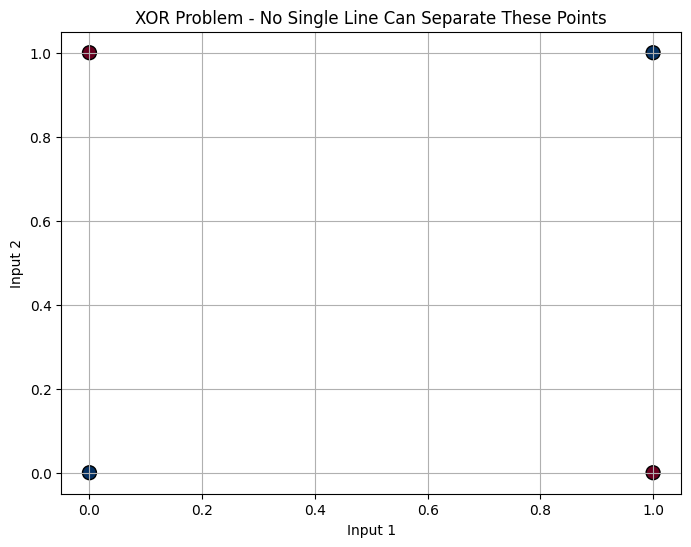

In [16]:

plt.figure(figsize=(8, 6))
plt.scatter([0, 1, 0, 1], [0, 0, 1, 1], c=[0, 1, 1, 0], cmap=plt.cm.RdBu_r, edgecolors='k', s=100)
plt.title('XOR Problem - No Single Line Can Separate These Points')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.grid(True)
plt.show()



This is why we need a neural network with hidden layers!

###4. Visualizing How Neural Networks Solve XOR
To solve XOR, a neural network transforms the input space to make the problem linearly separable. We'll implement a network with 3 hidden neurons and visualize this transformation:

In [17]:
class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size=1):
        self.hidden_weights = np.random.randn(input_size, hidden_size) / np.sqrt(input_size)
        self.hidden_bias = np.zeros(hidden_size)

        self.output_weights = np.random.randn(hidden_size, output_size) / np.sqrt(hidden_size)
        self.output_bias = np.zeros(output_size)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def forward(self, X):
        self.hidden_inputs = np.dot(X, self.hidden_weights) + self.hidden_bias
        self.hidden_outputs = self.sigmoid(self.hidden_inputs)

        self.final_inputs = np.dot(self.hidden_outputs, self.output_weights) + self.output_bias
        self.final_outputs = self.sigmoid(self.final_inputs)

        return self.final_outputs




### 4. Explore the XOR problem in3D and 2D, showing why a single neuron can’t solve it.




Epoch 0, Loss: 0.248810, Learning rate: 1.425000
Epoch 1000, Loss: 0.001386, Learning rate: 1.353750
Epoch 2000, Loss: 0.000548, Learning rate: 1.286062
Epoch 3000, Loss: 0.000341, Learning rate: 1.221759
Epoch 4000, Loss: 0.000250, Learning rate: 1.160671
Epoch 5000, Loss: 0.000198, Learning rate: 1.102638
Epoch 6000, Loss: 0.000166, Learning rate: 1.047506
Epoch 7000, Loss: 0.000143, Learning rate: 0.995131
Epoch 8000, Loss: 0.000127, Learning rate: 0.945374
Epoch 9000, Loss: 0.000114, Learning rate: 0.898105
Epoch 10000, Loss: 0.000104, Learning rate: 0.853200
Epoch 11000, Loss: 0.000096, Learning rate: 0.810540
Epoch 12000, Loss: 0.000090, Learning rate: 0.770013
Epoch 13000, Loss: 0.000084, Learning rate: 0.731512
Epoch 14000, Loss: 0.000080, Learning rate: 0.694937
Epoch 15000, Loss: 0.000076, Learning rate: 0.660190
Epoch 16000, Loss: 0.000073, Learning rate: 0.627181
Epoch 17000, Loss: 0.000070, Learning rate: 0.595821
Epoch 18000, Loss: 0.000067, Learning rate: 0.566030
Epoch 

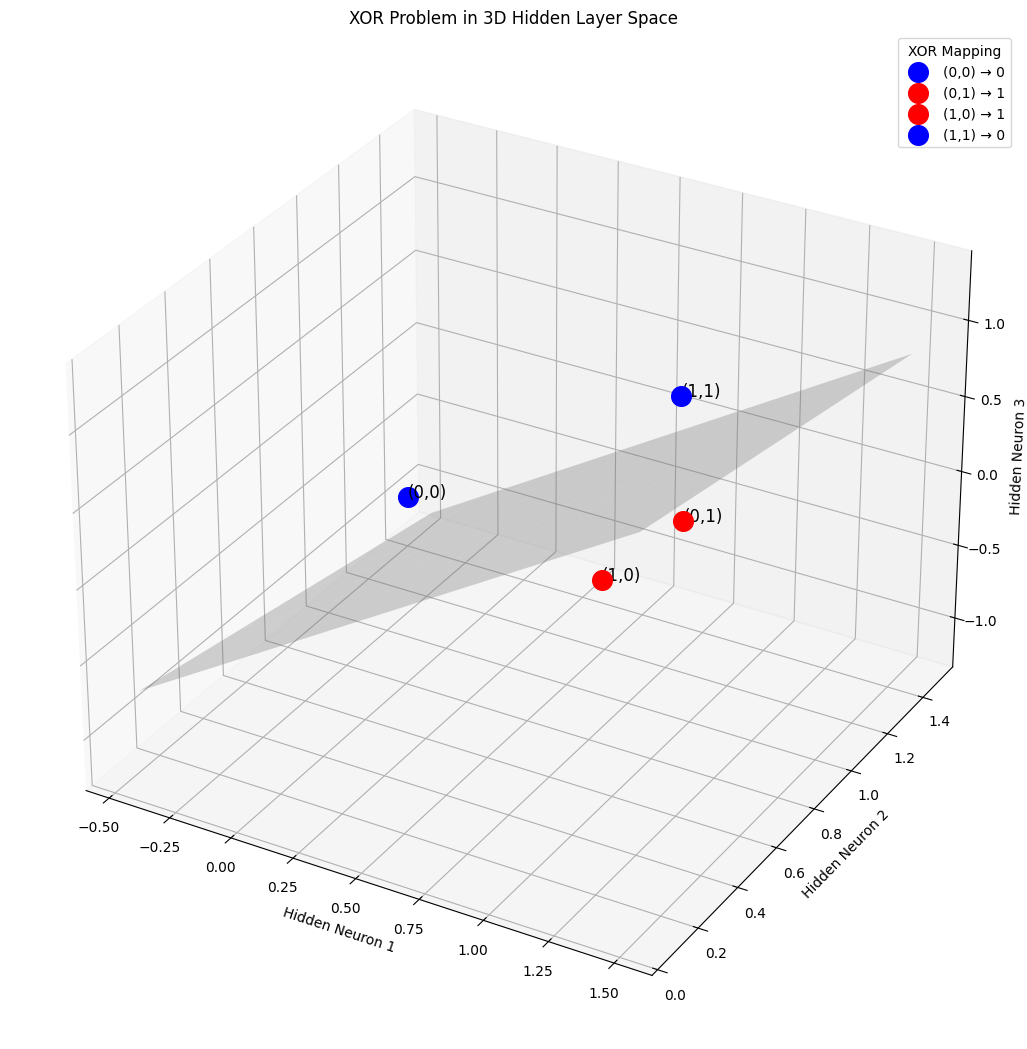

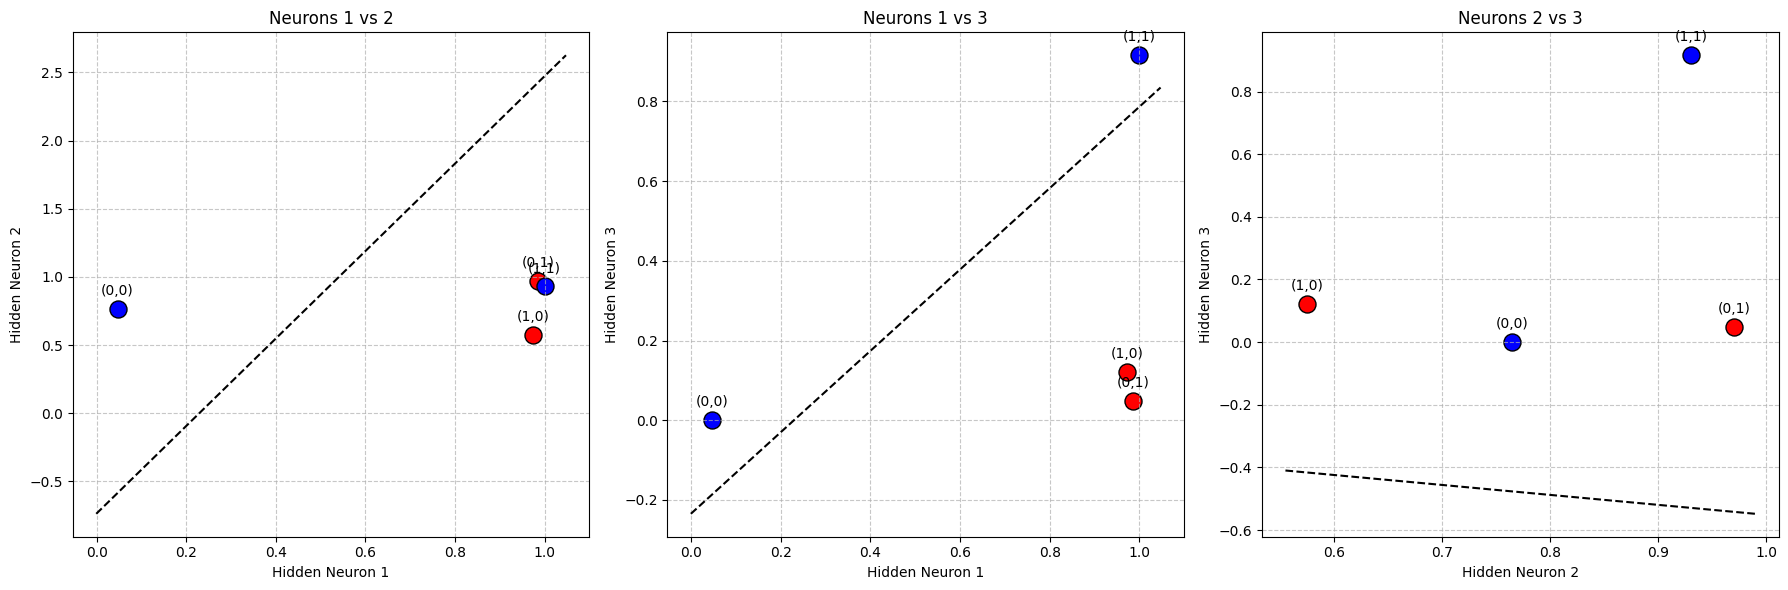

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize with larger weights to break symmetry effectively
        self.W1 = np.random.randn(input_size, hidden_size) * 1.0
        self.b1 = np.random.randn(1, hidden_size) * 0.5  # Non-zero bias initialization
        self.W2 = np.random.randn(hidden_size, output_size) * 1.0
        self.b2 = np.random.randn(1, output_size) * 0.5
        # Store for visualization
        self.hidden_outputs = None

    def sigmoid(self, x):
        # Add clipping to prevent overflow
        return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        # Forward propagation
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.hidden_outputs = self.a1  # Store for visualization
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def train(self, X, y, learning_rate=1.0, epochs=10000):
        y = y.reshape(-1, 1)  # Reshape y for proper dimensions
        best_loss = float('inf')
        best_weights = None

        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            error = y - output
            loss = np.mean(np.square(error))

            # Save best weights
            if loss < best_loss:
                best_loss = loss
                best_weights = {
                    'W1': self.W1.copy(),
                    'b1': self.b1.copy(),
                    'W2': self.W2.copy(),
                    'b2': self.b2.copy()
                }

            # Backpropagation
            d_output = error * self.sigmoid_derivative(output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

            # Update weights and biases
            self.W2 += self.a1.T.dot(d_output) * learning_rate
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.W1 += X.T.dot(d_hidden) * learning_rate
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

            # Implement learning rate decay
            if epoch % 1000 == 0:
                learning_rate *= 0.95
                print(f'Epoch {epoch}, Loss: {loss:.6f}, Learning rate: {learning_rate:.6f}')

        # Restore best weights
        print(f"\nRestoring best weights with loss: {best_loss:.6f}")
        self.W1 = best_weights['W1']
        self.b1 = best_weights['b1']
        self.W2 = best_weights['W2']
        self.b2 = best_weights['b2']

        # Show final predictions after training
        final_output = self.forward(X)
        print("\nFinal predictions:")
        for i, x_i in enumerate(X):
            print(f"Input: {x_i}, Target: {y[i][0]}, Prediction: {final_output[i][0]:.4f}")

def visualize_transformation_3d(model):
    """Visualize the transformation in 3D space for a model with 3 hidden neurons"""
    # Original XOR data
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([0, 1, 1, 0])

    # Get hidden outputs
    model.forward(X)
    hidden_outputs = model.hidden_outputs

    # Create 3D plot
    fig = plt.figure(figsize=(13, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Plot points
    colors = ['blue', 'red', 'red', 'blue']  # 0 = blue, 1 = red
    markers = ['o', 'o', 'o', 'o']

    for i, point in enumerate(hidden_outputs):
        ax.scatter(point[0], point[1], point[2],
                  c=colors[i], marker=markers[i], s=200,
                  label=f"({X[i][0]},{X[i][1]}) → {y[i]}")

        # Add text labels
        ax.text(point[0], point[1], point[2],
               f"({X[i][0]},{X[i][1]})", size=12)

    # Create meshgrid to visualize decision boundary (hyperplane)
    x_min, x_max = hidden_outputs[:, 0].min() - 0.5, hidden_outputs[:, 0].max() + 0.5
    y_min, y_max = hidden_outputs[:, 1].min() - 0.5, hidden_outputs[:, 1].max() + 0.5
    z_min, z_max = hidden_outputs[:, 2].min() - 0.5, hidden_outputs[:, 2].max() + 0.5

    # Create hyperplane: w₁x + w₂y + w₃z + b = 0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
    w1, w2, w3 = model.W2[0, 0], model.W2[1, 0], model.W2[2, 0]
    b = model.b2[0, 0]

    # Solve for z: z = -(w₁x + w₂y + b) / w₃
    if abs(w3) > 1e-6:  # Avoid division by zero
        zz = -(w1 * xx + w2 * yy + b) / w3
        # Plot the hyperplane
        surf = ax.plot_surface(xx, yy, zz, alpha=0.3, color='gray')

    # Set labels and title
    ax.set_xlabel('Hidden Neuron 1')
    ax.set_ylabel('Hidden Neuron 2')
    ax.set_zlabel('Hidden Neuron 3')
    ax.set_title('XOR Problem in 3D Hidden Layer Space')

    # Add unique labels only
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="XOR Mapping")

    plt.show()

def visualize_transformation_2d(model):
    """Visualize 2D projections of the 3D hidden space"""
    # Original XOR data
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([0, 1, 1, 0])

    # Get hidden outputs
    model.forward(X)
    hidden_outputs = model.hidden_outputs

    # Create figure with subplots for each 2D projection
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    projections = [(0, 1, 'Neurons 1 vs 2'),
                   (0, 2, 'Neurons 1 vs 3'),
                   (1, 2, 'Neurons 2 vs 3')]

    for i, (idx1, idx2, title) in enumerate(projections):
        ax = axes[i]

        # Plot points
        for j, point in enumerate(hidden_outputs):
            color = 'blue' if y[j] == 0 else 'red'
            ax.scatter(point[idx1], point[idx2], s=150, color=color, edgecolor='k')
            ax.annotate(f"({X[j][0]},{X[j][1]})",
                        (point[idx1], point[idx2]),
                        textcoords="offset points",
                        xytext=(0, 10),
                        ha='center')

        # Calculate and plot decision line
        w1 = model.W2[idx1, 0]
        w2 = model.W2[idx2, 0]
        b = model.b2[0, 0]

        if abs(w2) > 1e-6:  # Avoid division by zero
            x_min, x_max = ax.get_xlim()
            # Decision boundary line: w₁x + w₂y + b = 0
            # Solve for y: y = -(w₁x + b) / w₂
            x_vals = np.array([x_min, x_max])
            y_vals = -(w1 * x_vals + b) / w2
            ax.plot(x_vals, y_vals, '--', color='black')

        ax.set_title(title)
        ax.set_xlabel(f'Hidden Neuron {idx1+1}')
        ax.set_ylabel(f'Hidden Neuron {idx2+1}')
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Set random seed for reproducibility
np.random.seed(42)

# Create the model
input_size = 2    # XOR inputs
hidden_size = 3   # 3 neurons in hidden layer
output_size = 1   # XOR output

# Create and train the model
model = SimpleNeuralNetwork(input_size, hidden_size, output_size)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Train with improved parameters
model.train(X, y, learning_rate=1.5, epochs=25000)

# Visualize the transformed data in 3D
visualize_transformation_3d(model)

# Also show 2D projections for better clarity
visualize_transformation_2d(model)

####Interpreting the Results
Our 3D visualization demonstrates how the neural network transforms the XOR problem. In the hidden layer space:

- Points with the same output (0 or 1) are now grouped together
- A single hyperplane can now separate these groups
This confirms why we need at least one hidden layer with multiple neurons for XOR

###5. Building a Neural Network for Breast Cancer Classification
Now we're ready to apply neural networks to a real-world problem: classifying breast cancer as benign or malignant based on cell characteristics.
This code implements a simple feedforward neural network (multi-layer perceptron) to classify breast cancer data (benign vs. malignant) using the load_breast_cancer dataset from sklearn.

Key Steps:
1. Dataset Preparation: Load the dataset, standardize features using StandardScaler, and split into training and testing sets.

2. Neural Network (SimpleNeuralNetwork):

A basic neural network with:

- One hidden layer (8 neurons)
- Sigmoid activation for both hidden and output layers.
- Forward propagation calculates the output, and backpropagation adjusts weights using gradient descent with Mean Squared Error (MSE) loss.

3. Training: The model is trained for 2000 epochs, with updates to weights and biases every epoch, and loss is printed every 500 epochs.

4. Prediction & Evaluation: Makes predictions on training and test data, converting outputs to binary (0 or 1) based on a threshold of 0.5.

5. Accuracy is calculated by comparing predictions with true labels.

6. Loss Plot: Plots the loss curve to visualize training progress.

Epoch 0, Loss: 0.2388
Epoch 500, Loss: 0.0105
Epoch 1000, Loss: 0.0083
Epoch 1500, Loss: 0.0069
Training Accuracy: 0.9956
Test Accuracy: 0.9825


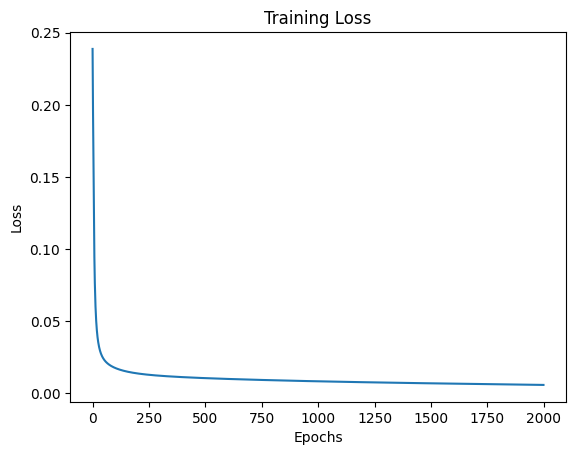

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size=1):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))
        self.losses = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def train(self, X, y, learning_rate=0.01, epochs=2000):
        y = y.reshape(-1, 1)
        for epoch in range(epochs):
            output = self.forward(X)
            error = y - output
            loss = np.mean(np.square(error))
            self.losses.append(loss)

            d_output = error * self.sigmoid_derivative(output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

            self.W2 += self.a1.T.dot(d_output) * learning_rate
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.W1 += X.T.dot(d_hidden) * learning_rate
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate
            if epoch % 500 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.4f}')

    def predict(self, X):
        return self.forward(X)

    def evaluate(self, X, y):
        predictions = self.predict(X)
        predictions_binary = (predictions > 0.5).astype(int)
        accuracy = np.mean(predictions_binary == y.reshape(-1, 1))
        return accuracy

# Load and prepare the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the neural network
input_size = X_train.shape[1]
hidden_size = 8  # Keep the hidden layer size relatively small
output_size = 1
learning_rate = 0.01
epochs = 2000

model = SimpleNeuralNetwork(input_size, hidden_size, output_size)
model.train(X_train, y_train, learning_rate, epochs)

# Evaluate the model
train_accuracy = model.evaluate(X_train, y_train)
test_accuracy = model.evaluate(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot the loss curve
plt.plot(model.losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

####Results
Our simple neural network achieves impressive results:

- Training Accuracy: 99.56%
- Test Accuracy: 98.25%

This high accuracy indicates that our model can effectively distinguish between benign and malignant tumors based on the provided features.

###6. Advanced Techniques for Better Performance
While our basic model performs well, we can implement several techniques to improve its generalization ability:

- L2 Regularization: Prevents overfitting by penalizing large weights
- Dropout: Randomly ignores neurons during training to enhance robustness
- Early Stopping: Stops training when validation performance stops improving
- Validation Set: Monitors generalization during training



Epoch 0, Loss: 0.250018, Val Loss: 0.239641
Early stopping at epoch 80
Training accuracy: 0.9863
Test accuracy: 0.9649


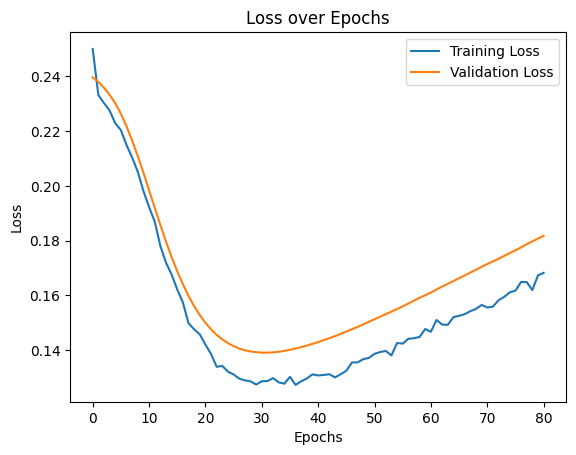


Sample predictions:
Sample 1: Prediction = 0.7951 (1), Actual = 1
Sample 2: Prediction = 0.0922 (0), Actual = 0
Sample 3: Prediction = 0.1513 (0), Actual = 0
Sample 4: Prediction = 0.9364 (1), Actual = 1
Sample 5: Prediction = 0.9628 (1), Actual = 1
Sample 6: Prediction = 0.0770 (0), Actual = 0
Sample 7: Prediction = 0.0777 (0), Actual = 0
Sample 8: Prediction = 0.2361 (0), Actual = 0
Sample 9: Prediction = 0.4703 (0), Actual = 1
Sample 10: Prediction = 0.9451 (1), Actual = 1


In [79]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class RobustNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size=1, lambda_reg=0.01, dropout_rate=0.1):
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.lambda_reg = lambda_reg  # Regularization parameter
        self.dropout_rate = dropout_rate # Dropout rate
        self.losses = []  # To store training losses
        self.val_losses = [] # To store validation losses
        self.best_val_loss = np.inf  # For early stopping
        self.patience = 50
        self.wait = 0

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X, training=True):
        # Forward pass - Layer 1 with Dropout
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        if training and self.dropout_rate > 0:
            self.dropout_mask1 = (np.random.rand(*self.a1.shape) > self.dropout_rate) / (1 - self.dropout_rate)
            self.a1 *= self.dropout_mask1
        elif not training and self.dropout_rate > 0:
            self.a1 *= (1 - self.dropout_rate)

        # Forward pass - Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def predict(self, X):
        return self.forward(X, training=False)

    def train(self, X, y, X_val, y_val, learning_rate=0.01, epochs=1000):
        y = y.reshape(-1, 1)
        y_val = y_val.reshape(-1, 1)

        for epoch in range(epochs):
            # Forward pass (training mode)
            output = self.forward(X, training=True)

            # Calculate loss with L2 regularization
            error = y - output
            loss = np.mean(np.square(error)) + self.lambda_reg * (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2)))
            self.losses.append(loss)

            # Backpropagation
            d_output = error * self.sigmoid_derivative(output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

            # Apply dropout to the gradients of the first layer
            if self.dropout_rate > 0 and hasattr(self, 'dropout_mask1'):
                d_hidden *= self.dropout_mask1

            # Update weights and biases
            self.W2 += self.a1.T.dot(d_output) * learning_rate
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.W1 += X.T.dot(d_hidden) * learning_rate
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

            # Apply L2 regularization
            self.W1 -= self.lambda_reg * self.W1 * learning_rate
            self.W2 -= self.lambda_reg * self.W2 * learning_rate

            # Early stopping: Monitor validation loss
            val_output = self.forward(X_val, training=False)
            val_error = y_val - val_output
            val_loss = np.mean(np.square(val_error)) + self.lambda_reg * (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2)))
            self.val_losses.append(val_loss)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.wait = 0
            else:
                self.wait += 1

            if self.wait >= self.patience:
                print(f"Early stopping at epoch {epoch}")
                break

            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.6f}, Val Loss: {val_loss:.6f}')

    def evaluate(self, X, y):
        predictions = self.predict(X)
        predictions_binary = (predictions > 0.5).astype(int)
        accuracy = np.mean(predictions_binary == y.reshape(-1, 1))
        return accuracy

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # Binary: malignant (0) or benign (1)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Initialize and train the model
input_size = X_train.shape[1]  # 30 features
hidden_size = 10              # Adjust hidden layer size
output_size = 1

model = RobustNeuralNetwork(input_size=input_size, hidden_size=hidden_size, output_size=output_size, lambda_reg=0.01, dropout_rate=0.1)
model.train(X_train, y_train, X_val, y_val, learning_rate=0.01, epochs=2000) # Increased epochs

# Evaluate
train_accuracy = model.evaluate(X_train, y_train)
test_accuracy = model.evaluate(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot learning curves
plt.plot(model.losses, label='Training Loss')
plt.plot(model.val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sample predictions
print("\nSample predictions:")
for i in range(min(10, len(X_test))):
    prediction = model.predict(X_test[i:i+1])[0][0]
    actual = y_test[i]
    print(f"Sample {i + 1}: Prediction = {prediction:.4f} ({(prediction > 0.5).astype(int)}), Actual = {actual}")

###Results of Advanced Model

Training accuracy: 98.63%
Test accuracy: 96.49%

Though the accuracy appears slightly lower than our simpler model, this is actually more robust and less likely to overfit. The early stopping mechanism halted training at epoch 80, preventing potential overfitting.

###7. Analyzing Sample Predictions
Let's analyze a few specific predictions to understand our model's strengths and limitations

Key Observations:

- Our model correctly classified 9 out of 10 samples
- For most correct predictions, the confidence level is high (>0.77 or <0.23)
- Sample 9 was misclassified with a prediction of 0.47 (slightly below our 0.5 threshold)
- The misclassification highlights a limitation with borderline cases

###Conclusion
In this notebook, we progressed from implementing a basic neuron to building a complete neural network for breast cancer classification. We explored fundamental concepts like:

How neurons learn through gradient descent
- Why hidden layers are necessary for complex problems?
- How to visualize transformations in neural networks?


Advanced techniques to enhance model performance

The final model achieves high accuracy in distinguishing between benign and malignant tumors, demonstrating the power of neural networks even without deep learning frameworks.

Future improvements could include:

- Additional hidden layers
- Alternative activation functions
- More sophisticated regularization techniques
- Hyperparameter optimization